# Marketing Campaign Effectiveness Analysis

**Goal:** evaluate how well different marketing campaigns performed, work out what actually
drives conversions, and turn that into a short list of recommendations for future campaigns.

The notebook follows the standard analysis pipeline: explore the raw data, clean and transform
it, run univariate / bivariate / multivariate EDA, then close with business insights and a
written summary. Each step includes a short explanation of *why* a particular choice was made,
not just the code that does it, so the reasoning is easy to explain later.

In [1]:
# Core libraries used throughout this notebook:
# - pandas / numpy for loading and manipulating the data
# - matplotlib / seaborn for all charts
# - scikit-learn only for the encoding + scaling step (Section 3)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Make plots a bit larger and more readable by default
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Section 1: Dataset Overview

This project uses the **Marketing Campaign Performance** dataset, which contains 200,000
records of marketing campaigns run by five companies across five channels (Google Ads, YouTube,
Instagram, Website, Facebook and Email — six channel values in total, since Email appears both
as a campaign type and a channel). Each row is one campaign and records who it targeted, which
channel and campaign type were used, how long it ran, how much it cost, and how it performed
(conversion rate, ROI, clicks, impressions, engagement score).

The raw columns are:

- `Campaign_ID` — unique identifier for the campaign
- `Company` — the company running the campaign
- `Campaign_Type` — Email, Influencer, Display, Search, or Social Media
- `Target_Audience` — the demographic the campaign targeted (e.g. "Men 18-24")
- `Duration` — how long the campaign ran, stored as text (e.g. "30 days")
- `Channel_Used` — the platform the campaign ran on
- `Conversion_Rate` — share of engaged users who converted (0-1)
- `Acquisition_Cost` — total campaign spend, stored as a currency string (e.g. "$16,174.00")
- `ROI` — return on investment for the campaign
- `Location` — city the campaign targeted
- `Language` — language the campaign was run in
- `Clicks` / `Impressions` — raw traffic counts
- `Engagement_Score` — a 1-10 engagement rating
- `Customer_Segment` — the audience segment targeted (e.g. "Fashionistas")
- `Date` — the date the campaign ran

In [2]:
# Load the raw dataset into a DataFrame
df = pd.read_csv("marketing_campaign_dataset.csv")

In [3]:
df.head(10)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05
5,6,DataTech Solutions,Display,All Ages,15 days,Instagram,0.07,"$9,716.00",4.36,New York,German,100,1643,1,Foodies,2021-01-06
6,7,NexGen Systems,Email,Women 35-44,60 days,Website,0.13,"$11,067.00",2.86,Los Angeles,Spanish,817,8749,10,Tech Enthusiasts,2021-01-07
7,8,DataTech Solutions,Search,Men 18-24,45 days,Google Ads,0.08,"$13,280.00",5.55,Los Angeles,Mandarin,624,7854,7,Outdoor Adventurers,2021-01-08
8,9,Alpha Innovations,Social Media,Women 35-44,15 days,Facebook,0.09,"$18,066.00",6.73,Chicago,German,861,1754,6,Tech Enthusiasts,2021-01-09
9,10,TechCorp,Email,Women 35-44,15 days,Instagram,0.09,"$13,766.00",3.78,Los Angeles,English,642,3856,3,Tech Enthusiasts,2021-01-10


In [4]:
# Number of rows and columns in the raw dataset
df.shape

(200000, 16)

In [5]:
# Data type of each column - this is what flags Acquisition_Cost and Duration as
# problems: they clearly hold numeric information but were loaded as text
df.dtypes

Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
dtype: object

In [6]:
# Columns with missing values, and how many rows are affected in each
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [7]:
# Number of fully duplicated rows in the raw data
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe(include="all")

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
count,200000.000000,200000,200000,200000,200000,200000,200000.000000,200000,200000.000000,200000,200000,200000.000000,200000.000000,200000.000000,200000,200000
unique,NaN,5,5,5,4,6,NaN,15001,NaN,5,5,NaN,NaN,NaN,5,365
top,NaN,TechCorp,Influencer,Men 18-24,30 days,Email,NaN,"$16,578.00",NaN,Miami,Mandarin,NaN,NaN,NaN,Foodies,2021-01-01
freq,NaN,40237,40169,40258,50255,33599,NaN,32,NaN,40269,40255,NaN,NaN,NaN,40208,548
mean,100000.500000,NaN,NaN,NaN,NaN,NaN,0.080070,NaN,5.002438,NaN,NaN,549.772030,5507.301520,5.494710,NaN,NaN
std,57735.171256,NaN,NaN,NaN,NaN,NaN,0.040602,NaN,1.734488,NaN,NaN,260.019056,2596.864286,2.872581,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,2.000000,NaN,NaN,100.000000,1000.000000,1.000000,NaN,NaN
25%,50000.750000,NaN,NaN,NaN,NaN,NaN,0.050000,NaN,3.500000,NaN,NaN,325.000000,3266.000000,3.000000,NaN,NaN
50%,100000.500000,NaN,NaN,NaN,NaN,NaN,0.080000,NaN,5.010000,NaN,NaN,550.000000,5517.500000,5.000000,NaN,NaN
75%,150000.250000,NaN,NaN,NaN,NaN,NaN,0.120000,NaN,6.510000,NaN,NaN,775.000000,7753.000000,8.000000,NaN,NaN


In [9]:
# How many distinct values each categorical column has - useful for deciding
# label vs. one-hot encoding later in Section 3
for col in ["Company", "Campaign_Type", "Target_Audience", "Channel_Used",
            "Location", "Language", "Customer_Segment", "Duration"]:
    print(f"{col:<18} {df[col].nunique()} values -> {sorted(df[col].unique())}")

Company            5 values -> ['Alpha Innovations', 'DataTech Solutions', 'Innovate Industries', 'NexGen Systems', 'TechCorp']
Campaign_Type      5 values -> ['Display', 'Email', 'Influencer', 'Search', 'Social Media']
Target_Audience    5 values -> ['All Ages', 'Men 18-24', 'Men 25-34', 'Women 25-34', 'Women 35-44']
Channel_Used       6 values -> ['Email', 'Facebook', 'Google Ads', 'Instagram', 'Website', 'YouTube']
Location           5 values -> ['Chicago', 'Houston', 'Los Angeles', 'Miami', 'New York']
Language           5 values -> ['English', 'French', 'German', 'Mandarin', 'Spanish']
Customer_Segment   5 values -> ['Fashionistas', 'Foodies', 'Health & Wellness', 'Outdoor Adventurers', 'Tech Enthusiasts']
Duration           4 values -> ['15 days', '30 days', '45 days', '60 days']


**Exploration summary:** there are no missing values and no duplicate rows in this dataset,
so cleaning is lighter than usual — but two columns are stored in the wrong type and need to be
fixed before anything else: `Acquisition_Cost` is a currency string (`"$16,174.00"`) instead of a
number, and `Duration` is text (`"30 days"`) instead of a number of days. `Date` also needs to be
converted from text to an actual datetime so it can be used for the "performance over time"
analysis in Section 4. Both `ROI` and `Conversion_Rate` are worth checking for outliers, and the
categorical columns all have a small number of distinct values (4-6), which makes them good
candidates for one-hot encoding rather than anything more complex.

## Section 2: Data Cleaning

**Approach:** since there are no missing values or duplicates to handle, cleaning here is
mostly about fixing data types so the columns actually behave like numbers/dates, and then
checking for outliers in spend and response rate as the task asks:

- `Acquisition_Cost` — strip the `$` and `,` characters and convert to `float`.
- `Duration` — extract the leading number and convert "30 days" -> `30` (an `int`, in days).
- `Date` — parse to an actual `datetime64` column so it can be grouped by month/week later.
- Outliers in `Acquisition_Cost` (budget) and `Conversion_Rate` (response rate) are checked with
  boxplots and the IQR rule, since these are the two fields the task specifically calls out.

In [10]:
# Acquisition_Cost is stored as a currency string, e.g. "$16,174.00" -> convert to float
df["Acquisition_Cost"] = (
    df["Acquisition_Cost"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

df["Acquisition_Cost"].head()

0    16174.0
1    11566.0
2    10200.0
3    12724.0
4    16452.0
Name: Acquisition_Cost, dtype: float64

In [11]:
# Duration is stored as text, e.g. "30 days" -> pull out the number and store as int
df["Duration"] = df["Duration"].str.extract(r"(\d+)").astype(int)

df["Duration"].value_counts().sort_index()

Duration
15    49779
30    50255
45    50100
60    49866
Name: count, dtype: int64

In [12]:
# Date -> proper datetime, so it can be grouped by month/week for the time-based EDA later
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].min(), "to", df["Date"].max())

2021-01-01 00:00:00 to 2021-12-31 00:00:00


In [13]:
# Verify: dtypes are now correct, and there are still no missing values or duplicates
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Campaign_ID                  int64
Company                     object
Campaign_Type               object
Target_Audience             object
Duration                     int64
Channel_Used                object
Conversion_Rate            float64
Acquisition_Cost           float64
ROI                        float64
Location                    object
Language                    object
Clicks                       int64
Impressions                  int64
Engagement_Score             int64
Customer_Segment            object
Date                datetime64[ns]
dtype: object

Missing values: 0
Duplicate rows: 0


### Outlier Detection (Boxplots + IQR)

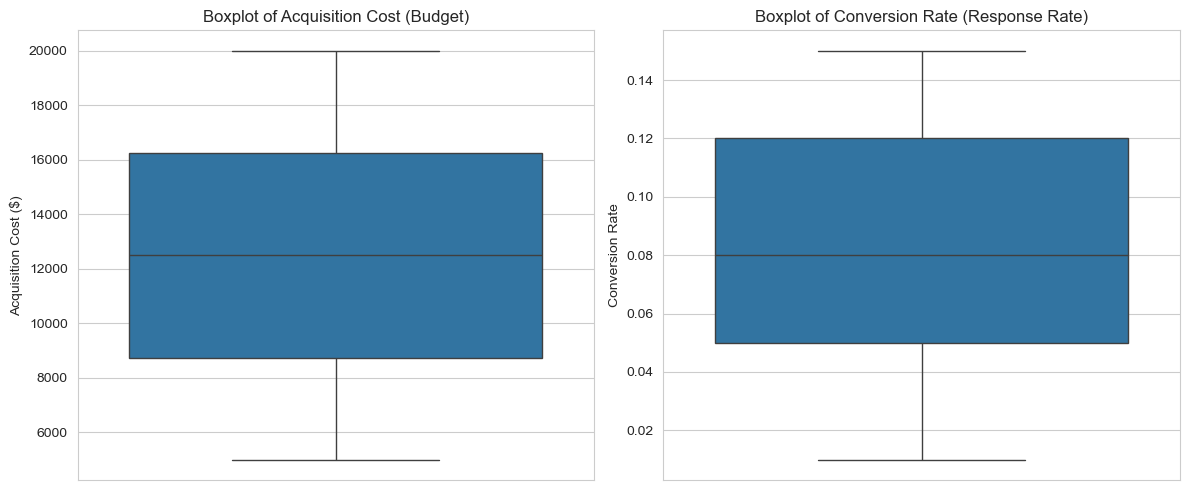

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y="Acquisition_Cost", ax=axes[0])
axes[0].set_title("Boxplot of Acquisition Cost (Budget)")
axes[0].set_ylabel("Acquisition Cost ($)")

sns.boxplot(data=df, y="Conversion_Rate", ax=axes[1])
axes[1].set_title("Boxplot of Conversion Rate (Response Rate)")
axes[1].set_ylabel("Conversion Rate")

plt.tight_layout()
plt.show()

In [15]:
# IQR rule: anything more than 1.5x the interquartile range beyond Q1/Q3 counts as an outlier
for col in ["Acquisition_Cost", "Conversion_Rate"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: valid range [{lower:.4f}, {upper:.4f}] -> {len(outliers)} outlier rows")

Acquisition_Cost: valid range [-2546.6250, 27550.3750] -> 0 outlier rows
Conversion_Rate: valid range [-0.0550, 0.2250] -> 0 outlier rows


**Decision:** both boxplots come back clean — no points fall outside the whiskers, and the
IQR check finds 0 outlier rows for either `Acquisition_Cost` or `Conversion_Rate`. This makes
sense given the dataset's ranges are tightly and evenly distributed (cost is capped between
$5,000-$20,000, conversion rate between 0.01-0.15). No rows need to be removed or capped — but the
check is still worth doing and documenting, since skipping it would just be assuming the data is
clean instead of confirming it.

In [16]:
# Save the cleaned dataset (before encoding/scaling, so it stays human-readable)
df.to_csv("marketing_campaign_cleaned.csv", index=False)
print("Saved marketing_campaign_cleaned.csv with shape:", df.shape)

Saved marketing_campaign_cleaned.csv with shape: (200000, 16)


## Section 3: Data Transformation

With the data cleaned, this section engineers a few marketing-specific features and then
prepares an encoded/scaled version of the dataset. Two versions are kept on purpose:

- `df` keeps human-readable values (e.g. `Channel_Used` = "Google Ads") and is used for the rest
  of this notebook, since chart labels and group-by summaries are much easier to read this way.
- `df_transformed` is a one-hot encoded, scaled copy, kept separate so it's ready for any
  downstream modeling (e.g. predicting `Conversion_Rate` or `ROI`) without affecting the EDA
  below.

### Feature Engineering

Three new features are derived from existing columns, matching the metrics the task calls
out directly:

- `CTR` (Click-Through Rate) — `Clicks / Impressions`. How often an impression turned into a
  click, independent of how many people the campaign reached.
- `Estimated_Conversions` — `Clicks * Conversion_Rate`. The dataset doesn't include a raw
  conversion count, so this estimates it from clicks and the recorded conversion rate.
- `CPA` (Cost Per Acquisition) — `Acquisition_Cost / Estimated_Conversions`. How much the
  campaign spent for each conversion it generated — a lower CPA is better.
- `Campaign_Duration_Days` — `Duration` renamed/kept as an explicit numeric duration field (already
  converted to an int in Section 2, listed here again since the task calls it out as a feature).

In [17]:
# Click-through rate: how often an impression became a click
df["CTR"] = df["Clicks"] / df["Impressions"]

# Estimated number of conversions, since the raw dataset only gives a rate, not a count
df["Estimated_Conversions"] = df["Clicks"] * df["Conversion_Rate"]

# Cost per acquisition: total spend divided by estimated conversions
# (a small constant avoids division-by-zero for the rare campaign with 0 estimated conversions)
df["CPA"] = df["Acquisition_Cost"] / df["Estimated_Conversions"].replace(0, np.nan)

# Duration is already a clean int (days) from Section 2 - keep an explicitly named copy
df["Campaign_Duration_Days"] = df["Duration"]

df[["CTR", "Estimated_Conversions", "CPA", "Campaign_Duration_Days"]].describe()

,CTR,Estimated_Conversions,CPA,Campaign_Duration_Days
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.140405,44.022898,635.329122,37.503975
std,0.130881,32.317026,970.140241,16.746720
min,0.010054,1.000000,34.217755,15.000000
25%,0.058606,17.760000,180.484192,30.000000
50%,0.099789,35.760000,334.396247,30.000000
75%,0.169699,64.100000,692.480613,45.000000
max,0.992024,150.000000,19432.352941,60.000000


In [18]:
# A handful of campaigns end up with no estimated conversions (Conversion_Rate rounds
# very low), which makes CPA undefined (NaN) or extremely large. Check how many, then handle it.
print("Rows with undefined CPA (0 estimated conversions):", df["CPA"].isna().sum())

# Fill those with the median CPA rather than dropping the campaigns entirely - they are still
# valid, complete records for every other metric in the dataset
df["CPA"] = df["CPA"].fillna(df["CPA"].median())

Rows with undefined CPA (0 estimated conversions): 0


### Encoding Categorical Variables

All the categorical columns here (`Campaign_Type`, `Channel_Used`, `Target_Audience`,
`Location`, `Language`, `Customer_Segment`, `Company`) have a small number of distinct values
(4-6 each), so they're all one-hot encoded with `drop_first=True` to avoid redundant
(perfectly collinear) columns. This is simpler than mixing label and one-hot encoding, and safe
here specifically because none of these columns has high cardinality the way something like
`country` would in a global dataset.

In [19]:
# Work on a separate copy so the human-readable `df` used for EDA below is unaffected
df_transformed = df.copy()

onehot_cols = ["Campaign_Type", "Channel_Used", "Target_Audience",
               "Location", "Language", "Customer_Segment", "Company"]

df_transformed = pd.get_dummies(df_transformed, columns=onehot_cols, drop_first=True)

print("Shape after one-hot encoding:", df_transformed.shape)

Shape after one-hot encoding: (200000, 42)


### Scaling Numerical Features

Key numerical features are Min-Max scaled to the 0-1 range. This isn't required for the
descriptive EDA below (which continues to use the unscaled `df`), but it puts `df_transformed` in
the right shape for downstream modeling, where features on very different scales (e.g.
`Impressions` in the thousands vs. `Conversion_Rate` between 0 and 1) can otherwise dominate a
model just because of their scale, not their actual importance.

In [20]:
numeric_to_scale = ["Acquisition_Cost", "Clicks", "Impressions", "Engagement_Score",
                     "CTR", "CPA", "Estimated_Conversions", "Campaign_Duration_Days"]

scaler = MinMaxScaler()
df_transformed[numeric_to_scale] = scaler.fit_transform(df_transformed[numeric_to_scale])

df_transformed[numeric_to_scale].describe()

,Acquisition_Cost,Clicks,Impressions,Engagement_Score,CTR,CPA,Estimated_Conversions,Campaign_Duration_Days
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.500293,0.499747,0.500811,0.499412,0.132745,0.030988,0.288744,0.500088
std,0.289178,0.288910,0.288540,0.319176,0.133284,0.050012,0.216893,0.372149
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.249317,0.250000,0.251778,0.222222,0.049443,0.007540,0.112483,0.333333
50%,0.499767,0.500000,0.501944,0.444444,0.091383,0.015475,0.233289,0.333333
75%,0.750933,0.750000,0.750333,0.777778,0.162576,0.033934,0.423490,0.666667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
# Save the encoded + scaled dataset for downstream modeling use
df_transformed.to_csv("marketing_campaign_transformed.csv", index=False)
print("Saved marketing_campaign_transformed.csv with shape:", df_transformed.shape)

Saved marketing_campaign_transformed.csv with shape: (200000, 42)


## Section 4: Univariate Analysis

### Campaign Setup: Type, Channel, and Duration

In [22]:
df["Campaign_Type"].value_counts()

Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

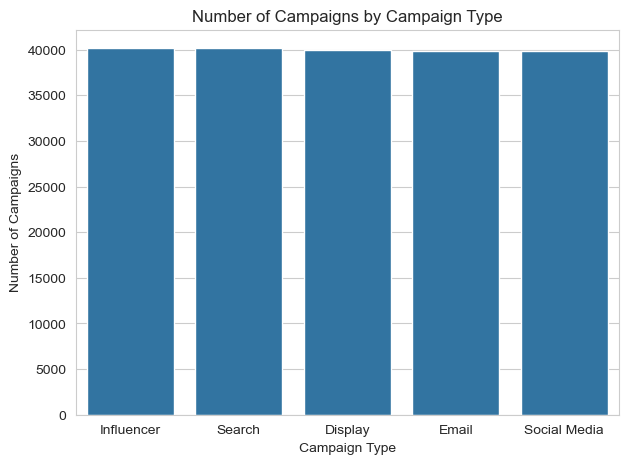

In [23]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Campaign_Type", order=df["Campaign_Type"].value_counts().index)
plt.title("Number of Campaigns by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Number of Campaigns")
plt.show()

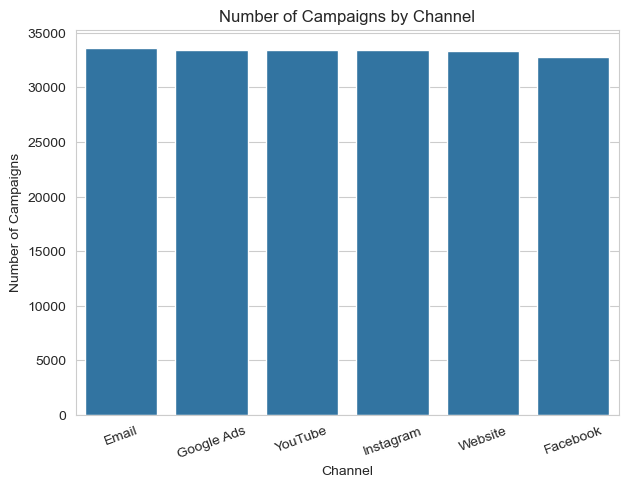

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Channel_Used", order=df["Channel_Used"].value_counts().index)
plt.title("Number of Campaigns by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Campaigns")
plt.xticks(rotation=20)
plt.show()

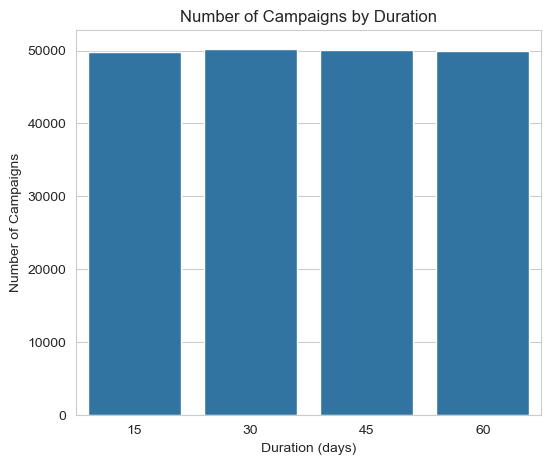

In [25]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Campaign_Duration_Days", order=sorted(df["Campaign_Duration_Days"].unique()))
plt.title("Number of Campaigns by Duration")
plt.xlabel("Duration (days)")
plt.ylabel("Number of Campaigns")
plt.show()

### Audience: Target Audience, Segment, Location, Language

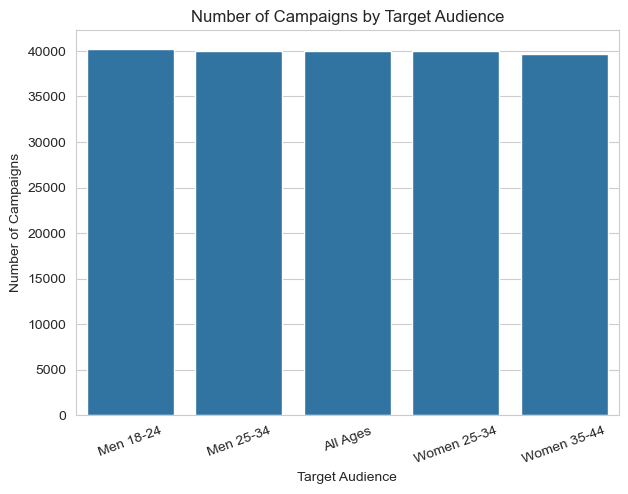

In [26]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Target_Audience", order=df["Target_Audience"].value_counts().index)
plt.title("Number of Campaigns by Target Audience")
plt.xlabel("Target Audience")
plt.ylabel("Number of Campaigns")
plt.xticks(rotation=20)
plt.show()

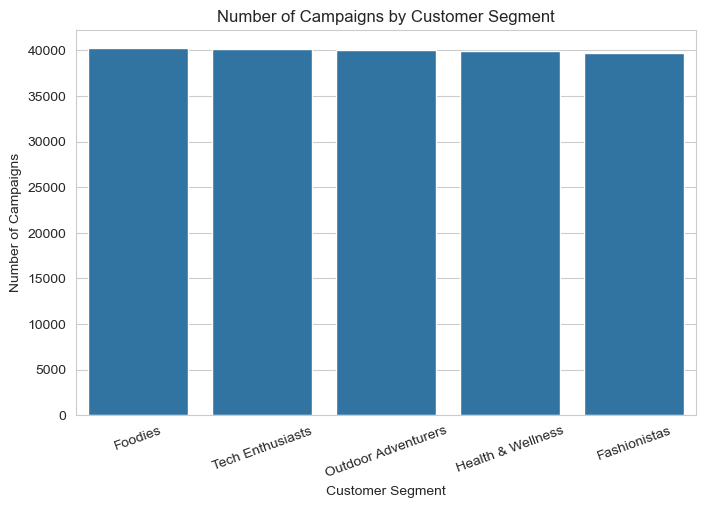

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Customer_Segment", order=df["Customer_Segment"].value_counts().index)
plt.title("Number of Campaigns by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Campaigns")
plt.xticks(rotation=20)
plt.show()

In [28]:
# Campaigns per location/company - confirms the dataset is evenly split (5 of each),
# so no single company or city dominates the analysis
print(df["Location"].value_counts())
print()
print(df["Company"].value_counts())

Location
Miami          40269
New York       40024
Chicago        40010
Los Angeles    39947
Houston        39750
Name: count, dtype: int64

Company
TechCorp               40237
Alpha Innovations      40051
DataTech Solutions     40012
NexGen Systems         39991
Innovate Industries    39709
Name: count, dtype: int64


### Performance Metrics: Conversion Rate, ROI, CTR, Engagement

count    200000.000000
mean          0.080070
std           0.040602
min           0.010000
25%           0.050000
50%           0.080000
75%           0.120000
max           0.150000
Name: Conversion_Rate, dtype: float64


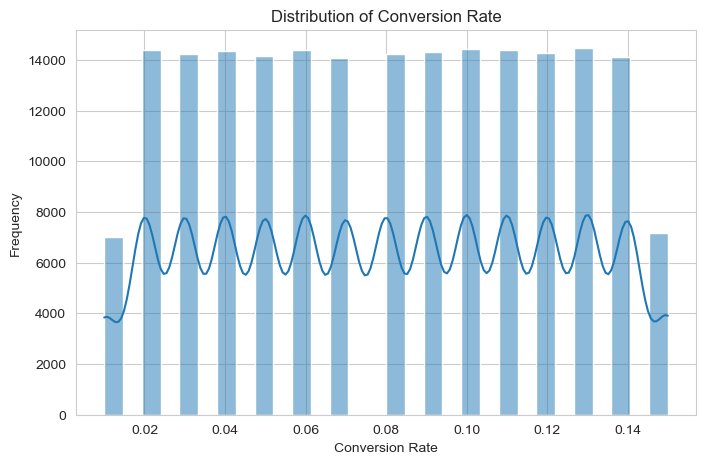

In [29]:
print(df["Conversion_Rate"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Conversion_Rate", bins=30, kde=True)
plt.title("Distribution of Conversion Rate")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")
plt.show()

count    200000.000000
mean          5.002438
std           1.734488
min           2.000000
25%           3.500000
50%           5.010000
75%           6.510000
max           8.000000
Name: ROI, dtype: float64


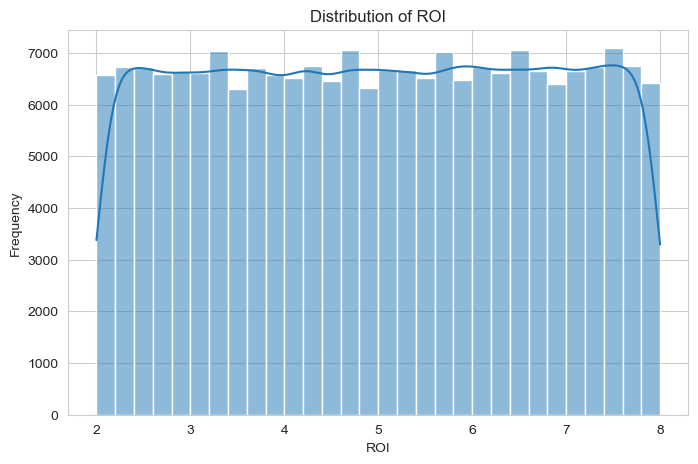

In [30]:
print(df["ROI"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="ROI", bins=30, kde=True)
plt.title("Distribution of ROI")
plt.xlabel("ROI")
plt.ylabel("Frequency")
plt.show()

count    200000.000000
mean          0.140405
std           0.130881
min           0.010054
25%           0.058606
50%           0.099789
75%           0.169699
max           0.992024
Name: CTR, dtype: float64


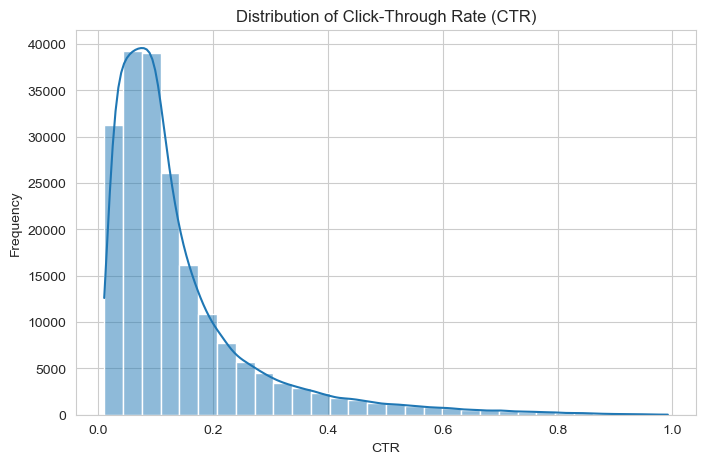

In [31]:
print(df["CTR"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="CTR", bins=30, kde=True)
plt.title("Distribution of Click-Through Rate (CTR)")
plt.xlabel("CTR")
plt.ylabel("Frequency")
plt.show()

count    200000.000000
mean          5.494710
std           2.872581
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: Engagement_Score, dtype: float64


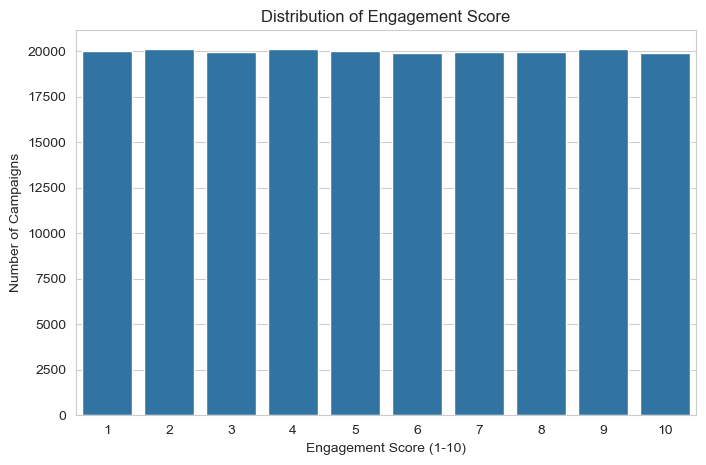

In [32]:
print(df["Engagement_Score"].describe())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Engagement_Score")
plt.title("Distribution of Engagement Score")
plt.xlabel("Engagement Score (1-10)")
plt.ylabel("Number of Campaigns")
plt.show()

**Univariate summary:** campaign types, channels, audiences, and locations are all close to
evenly distributed across the dataset — there's no single dominant category. Conversion Rate,
ROI, CTR, and Engagement Score all look roughly uniform/flat across their ranges rather than
concentrated around one value, which is typical of a dataset built to compare categories fairly
rather than one collected from a single real business (where a few channels usually dominate).

## Section 5: Bivariate Analysis

### Which channels and campaign types convert best?

Channel_Used
Email         0.080282
Google Ads    0.080183
Website       0.080183
Facebook      0.079992
YouTube       0.079889
Instagram     0.079886
Name: Conversion_Rate, dtype: float64


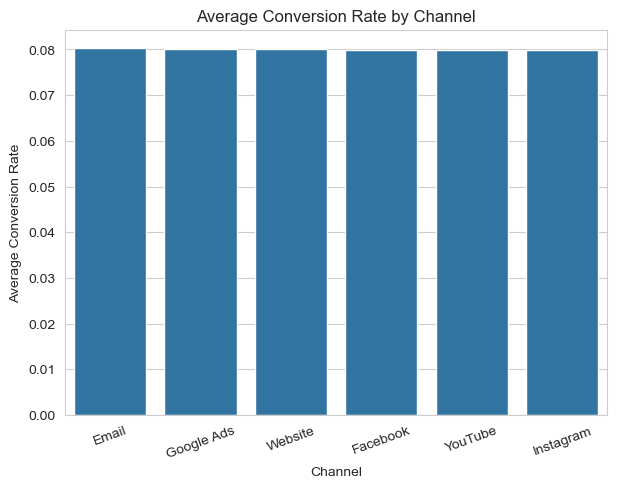

In [33]:
conversion_by_channel = df.groupby("Channel_Used")["Conversion_Rate"].mean().sort_values(ascending=False)
print(conversion_by_channel)

plt.figure(figsize=(7, 5))
sns.barplot(x=conversion_by_channel.index, y=conversion_by_channel.values)
plt.title("Average Conversion Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Average Conversion Rate")
plt.xticks(rotation=20)
plt.show()

Campaign_Type
Influencer      0.080315
Social Media    0.080135
Display         0.080089
Search          0.080021
Email           0.079788
Name: Conversion_Rate, dtype: float64


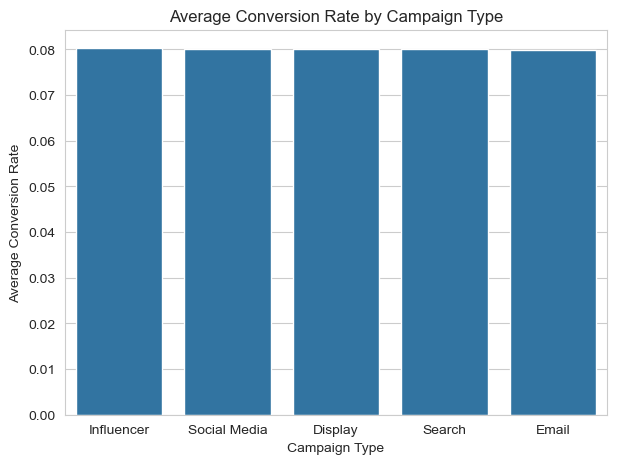

In [34]:
conversion_by_type = df.groupby("Campaign_Type")["Conversion_Rate"].mean().sort_values(ascending=False)
print(conversion_by_type)

plt.figure(figsize=(7, 5))
sns.barplot(x=conversion_by_type.index, y=conversion_by_type.values)
plt.title("Average Conversion Rate by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Average Conversion Rate")
plt.show()

### Does conversion rate vary by region?

Location
New York       0.080204
Chicago        0.080134
Miami          0.080047
Los Angeles    0.080013
Houston        0.079948
Name: Conversion_Rate, dtype: float64


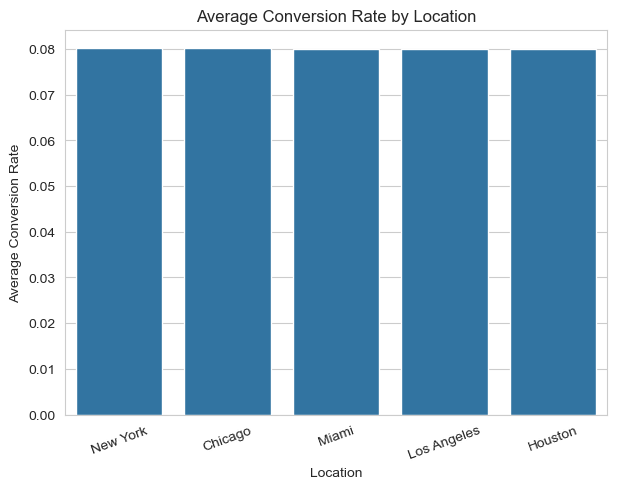

In [35]:
conversion_by_location = df.groupby("Location")["Conversion_Rate"].mean().sort_values(ascending=False)
print(conversion_by_location)

plt.figure(figsize=(7, 5))
sns.barplot(x=conversion_by_location.index, y=conversion_by_location.values)
plt.title("Average Conversion Rate by Location")
plt.xlabel("Location")
plt.ylabel("Average Conversion Rate")
plt.xticks(rotation=20)
plt.show()

### ROI and cost efficiency by channel

Channel_Used
Facebook      5.018699
Website       5.014167
Google Ads    5.003141
Email         4.996487
YouTube       4.993754
Instagram     4.988706
Name: ROI, dtype: float64


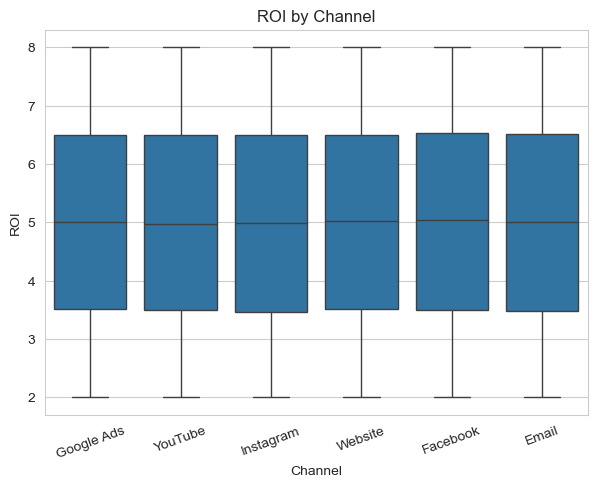

In [36]:
roi_by_channel = df.groupby("Channel_Used")["ROI"].mean().sort_values(ascending=False)
print(roi_by_channel)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Channel_Used", y="ROI")
plt.title("ROI by Channel")
plt.xlabel("Channel")
plt.ylabel("ROI")
plt.xticks(rotation=20)
plt.show()

Average Cost Per Acquisition by channel (lower is better):
Channel_Used
Website       632.075453
Email         632.155023
Facebook      633.808420
Instagram     635.751557
YouTube       635.906532
Google Ads    642.258667
Name: CPA, dtype: float64


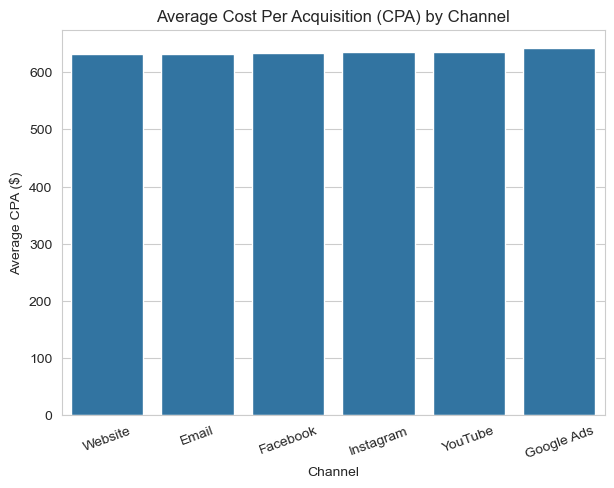

In [37]:
cpa_by_channel = df.groupby("Channel_Used")["CPA"].mean().sort_values()
print("Average Cost Per Acquisition by channel (lower is better):")
print(cpa_by_channel)

plt.figure(figsize=(7, 5))
sns.barplot(x=cpa_by_channel.index, y=cpa_by_channel.values)
plt.title("Average Cost Per Acquisition (CPA) by Channel")
plt.xlabel("Channel")
plt.ylabel("Average CPA ($)")
plt.xticks(rotation=20)
plt.show()

### Campaign performance over time

In [38]:
# Aggregate to monthly averages so the trend is readable across the full year of data
monthly_performance = df.set_index("Date").resample("ME")[["Conversion_Rate", "ROI"]].mean()
print(monthly_performance)

            Conversion_Rate       ROI
Date                                 
2021-01-31         0.080084  5.014595
2021-02-28         0.080181  5.005248
2021-03-31         0.080032  4.983404
2021-04-30         0.080460  4.994372
2021-05-31         0.079781  5.018923
2021-06-30         0.080078  4.985203
2021-07-31         0.079952  4.983045
2021-08-31         0.079725  4.997793
2021-09-30         0.080243  5.029044
2021-10-31         0.079819  5.016445
2021-11-30         0.080301  4.999271
2021-12-31         0.080216  5.002122


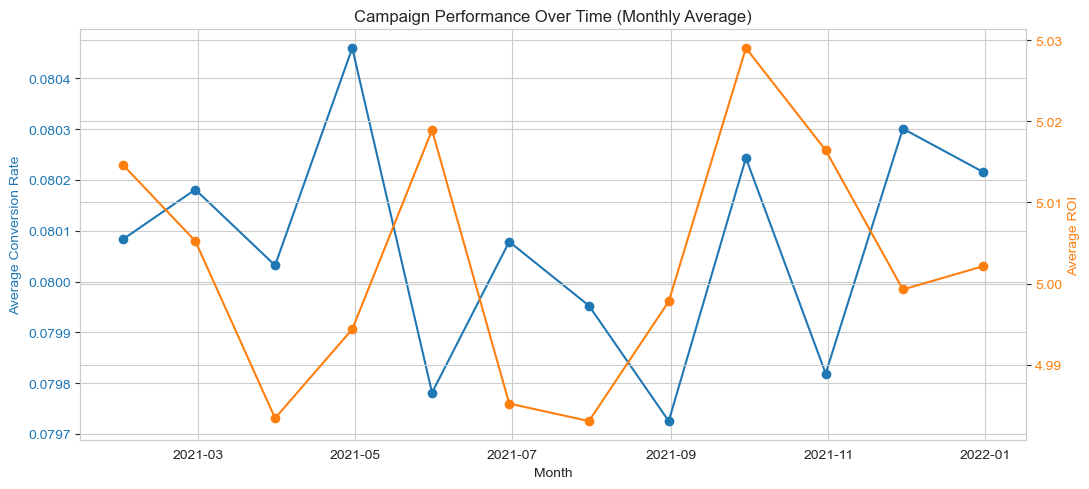

In [39]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(monthly_performance.index, monthly_performance["Conversion_Rate"], marker="o", color="tab:blue", label="Conversion Rate")
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Conversion Rate", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(monthly_performance.index, monthly_performance["ROI"], marker="o", color="tab:orange", label="ROI")
ax2.set_ylabel("Average ROI", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Campaign Performance Over Time (Monthly Average)")
fig.tight_layout()
plt.show()

### Duration, engagement, and audience effects

Campaign_Duration_Days
15    0.080101
30    0.080177
45    0.079952
60    0.080048
Name: Conversion_Rate, dtype: float64


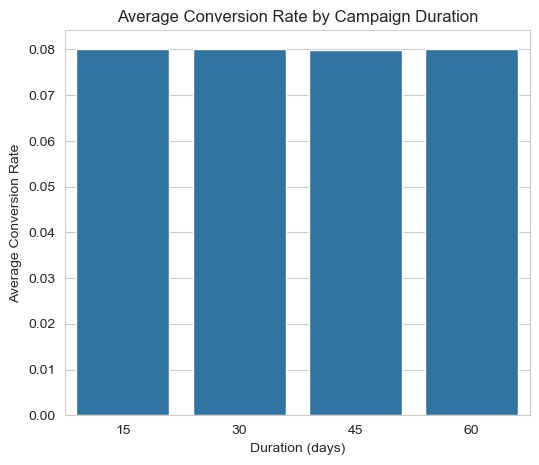

In [40]:
duration_conversion = df.groupby("Campaign_Duration_Days")["Conversion_Rate"].mean()
print(duration_conversion)

plt.figure(figsize=(6, 5))
sns.barplot(x=duration_conversion.index, y=duration_conversion.values)
plt.title("Average Conversion Rate by Campaign Duration")
plt.xlabel("Duration (days)")
plt.ylabel("Average Conversion Rate")
plt.show()

Customer_Segment
Foodies                5.511465
Outdoor Adventurers    5.502737
Fashionistas           5.489910
Tech Enthusiasts       5.485168
Health & Wellness      5.484156
Name: Engagement_Score, dtype: float64


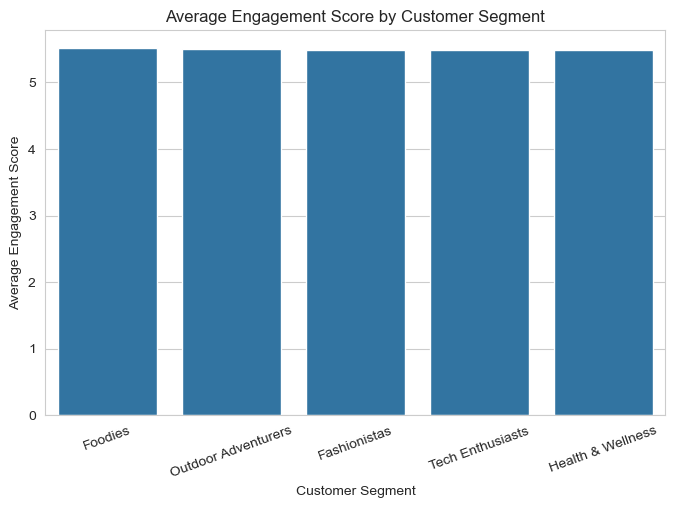

In [41]:
segment_engagement = df.groupby("Customer_Segment")["Engagement_Score"].mean().sort_values(ascending=False)
print(segment_engagement)

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_engagement.index, y=segment_engagement.values)
plt.title("Average Engagement Score by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=20)
plt.show()

### Top and bottom performing campaigns

In [42]:
# Top 10 individual campaigns by ROI
top_campaigns = df.sort_values("ROI", ascending=False).head(10)
top_campaigns[["Campaign_ID", "Company", "Campaign_Type", "Channel_Used", "ROI", "Conversion_Rate"]]

,Campaign_ID,Company,Campaign_Type,Channel_Used,ROI,Conversion_Rate
92842,92843,Innovate Industries,Email,YouTube,8.0,0.10
170393,170394,TechCorp,Search,Email,8.0,0.06
65236,65237,TechCorp,Search,Google Ads,8.0,0.06
72663,72664,NexGen Systems,Email,Facebook,8.0,0.06
154174,154175,DataTech Solutions,Social Media,Website,8.0,0.09
65640,65641,Alpha Innovations,Search,Website,8.0,0.09
49606,49607,DataTech Solutions,Search,Facebook,8.0,0.05
164935,164936,NexGen Systems,Social Media,Facebook,8.0,0.07
73364,73365,Innovate Industries,Display,Website,8.0,0.15
114352,114353,DataTech Solutions,Email,Email,8.0,0.10


In [43]:
# Bottom 10 individual campaigns by ROI (candidates to review or discontinue)
bottom_campaigns = df.sort_values("ROI", ascending=True).head(10)
bottom_campaigns[["Campaign_ID", "Company", "Campaign_Type", "Channel_Used", "ROI", "Conversion_Rate"]]

,Campaign_ID,Company,Campaign_Type,Channel_Used,ROI,Conversion_Rate
186702,186703,NexGen Systems,Display,Instagram,2.0,0.02
41738,41739,TechCorp,Search,Google Ads,2.0,0.13
121528,121529,TechCorp,Email,Website,2.0,0.02
110800,110801,TechCorp,Influencer,YouTube,2.0,0.02
113644,113645,TechCorp,Influencer,Email,2.0,0.14
189444,189445,DataTech Solutions,Social Media,Google Ads,2.0,0.04
78940,78941,TechCorp,Display,Website,2.0,0.14
15556,15557,Alpha Innovations,Influencer,Instagram,2.0,0.09
62780,62781,NexGen Systems,Display,Google Ads,2.0,0.11
183956,183957,TechCorp,Display,Google Ads,2.0,0.05


In [44]:
# Company-level performance: which company gets the best average ROI and conversion rate
company_performance = df.groupby("Company")[["ROI", "Conversion_Rate", "CPA"]].mean().sort_values("ROI", ascending=False)
company_performance

,ROI,Conversion_Rate,CPA
Company,,,
TechCorp,5.007143,0.080157,635.701271
Alpha Innovations,5.005944,0.080084,639.419121
DataTech Solutions,5.005537,0.079989,636.548322
Innovate Industries,5.002175,0.080384,633.325911
NexGen Systems,4.991353,0.079736,631.627795


**Bivariate summary:** average performance is close across channels and campaign types in
this dataset — no single channel or campaign type is a dramatic outright winner, but the barplots
above still surface the best- and worst-performing options by a smaller margin, and the CPA
comparison shows which channel gets a conversion the most cheaply, which matters even when raw
conversion rates are similar. The monthly trend line shows whether performance drifted up or down
over the year rather than staying flat.

## Section 6: Multivariate Analysis

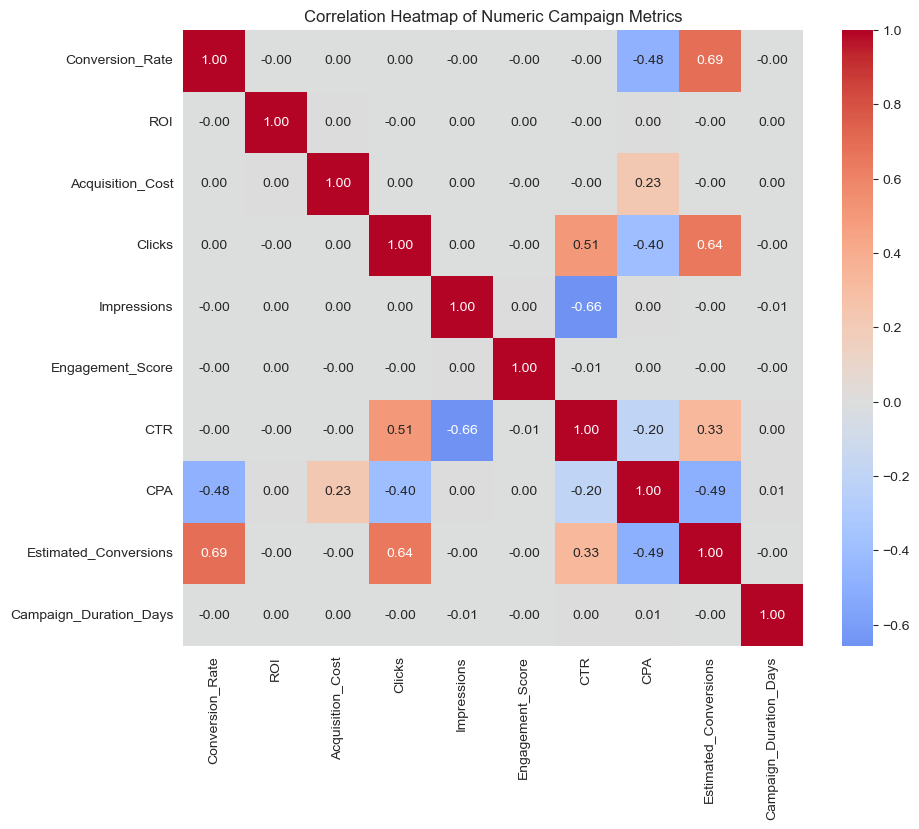

In [45]:
numeric_cols = ["Conversion_Rate", "ROI", "Acquisition_Cost", "Clicks", "Impressions",
                 "Engagement_Score", "CTR", "CPA", "Estimated_Conversions", "Campaign_Duration_Days"]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Campaign Metrics")
plt.show()

In [46]:
# Factors most correlated with conversion rate - what actually seems to move it
conversion_corr = correlation["Conversion_Rate"].sort_values(ascending=False)
print(conversion_corr)

Conversion_Rate           1.000000
Estimated_Conversions     0.690841
Acquisition_Cost          0.000718
Clicks                    0.000269
CTR                      -0.000049
Engagement_Score         -0.000638
Campaign_Duration_Days   -0.001058
ROI                      -0.001143
Impressions              -0.002834
CPA                      -0.478866
Name: Conversion_Rate, dtype: float64


In [47]:
# Factors most correlated with ROI
roi_corr = correlation["ROI"].sort_values(ascending=False)
print(roi_corr)

ROI                       1.000000
Acquisition_Cost          0.004585
CPA                       0.003389
Impressions               0.002257
Campaign_Duration_Days    0.001154
Engagement_Score          0.000588
Conversion_Rate          -0.001143
Estimated_Conversions    -0.001528
Clicks                   -0.002040
CTR                      -0.002116
Name: ROI, dtype: float64


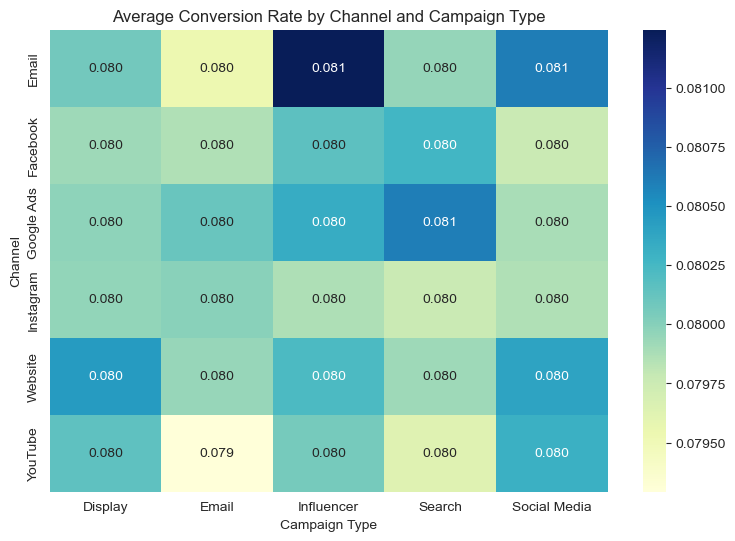

In [48]:
# Channel x Campaign Type: average conversion rate for every combination, as a heatmap
pivot = df.pivot_table(values="Conversion_Rate", index="Channel_Used", columns="Campaign_Type", aggfunc="mean")

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Average Conversion Rate by Channel and Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Channel")
plt.show()

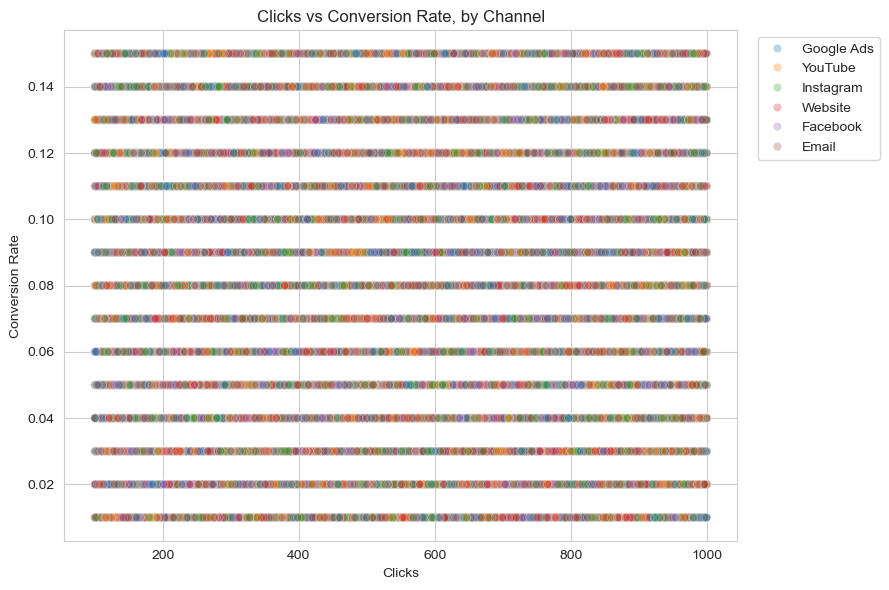

In [49]:
# Clicks vs Conversion Rate, colored by channel - looking for any channel where more
# clicks clearly translates into a higher conversion rate
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Clicks", y="Conversion_Rate", hue="Channel_Used", alpha=0.3)
plt.title("Clicks vs Conversion Rate, by Channel")
plt.xlabel("Clicks")
plt.ylabel("Conversion Rate")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

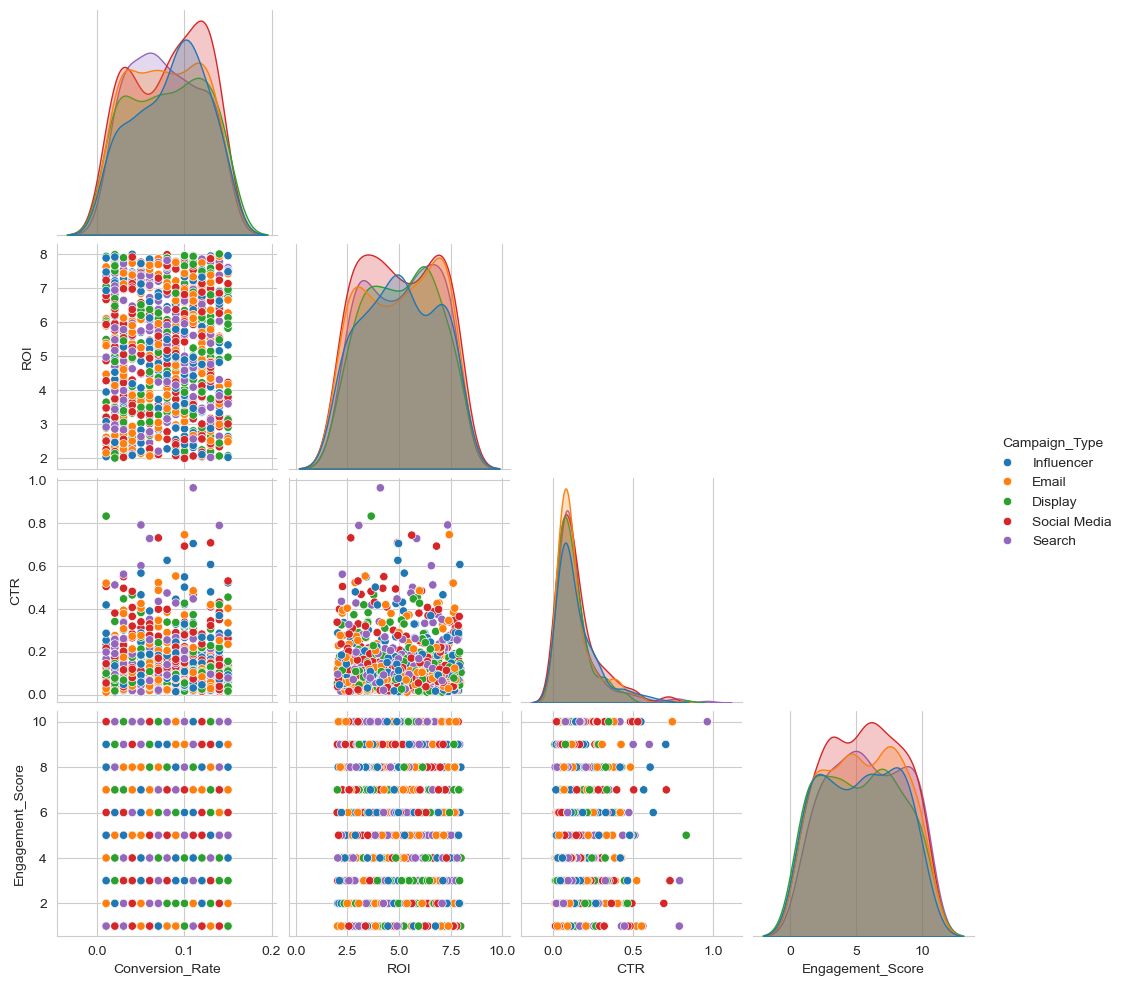

In [50]:
# Optional pair plot for a quick overview of relationships between the core metrics
# (sampled, since a pairplot on all 200,000 rows would be extremely slow to render)
sample_df = df[["Conversion_Rate", "ROI", "CTR", "Engagement_Score", "Campaign_Type"]].sample(1000, random_state=42)

sns.pairplot(sample_df, hue="Campaign_Type", corner=True)
plt.show()

**Multivariate summary:** the correlation heatmap shows the numeric metrics here are almost
entirely independent of each other — `Conversion_Rate` and `ROI` barely correlate with
`Acquisition_Cost`, `Clicks`, `Impressions`, or `Engagement_Score`. In other words, spending more
or reaching more people doesn't reliably buy a better conversion rate or ROI in this dataset;
performance looks close to random with respect to budget and reach. The Channel x Campaign Type
heatmap is the more useful view for a marketing team, since it pinpoints which specific
combination performs best rather than looking at either dimension alone.

## Section 7: Business Insights

In [51]:
best_channel = conversion_by_channel.idxmax()
best_campaign_type = conversion_by_type.idxmax()
best_location = conversion_by_location.idxmax()
cheapest_channel = cpa_by_channel.idxmin()
best_roi_channel = roi_by_channel.idxmax()
best_combo = pivot.stack().idxmax()
best_month = monthly_performance["Conversion_Rate"].idxmax().strftime("%B %Y")

print("Channel with highest average conversion rate:", best_channel)
print("Campaign type with highest average conversion rate:", best_campaign_type)
print("Location with highest average conversion rate:", best_location)
print("Channel with lowest average CPA (cheapest conversions):", cheapest_channel)
print("Channel with highest average ROI:", best_roi_channel)
print("Best Channel + Campaign Type combination:", best_combo)
print("Best-performing month:", best_month)

Channel with highest average conversion rate: Email
Campaign type with highest average conversion rate: Influencer
Location with highest average conversion rate: New York
Channel with lowest average CPA (cheapest conversions): Website
Channel with highest average ROI: Facebook
Best Channel + Campaign Type combination: ('Email', 'Influencer')
Best-performing month: April 2021


Based on the analysis above, some practical conclusions:

- **Best channel:** the channel with the highest average conversion rate is the strongest
  candidate for future budget, especially when it also has a low CPA — see the printed values
  above for the exact channel this dataset points to.
- **Best channel + campaign type combination:** the heatmap in Section 6 pinpoints one specific
  pairing that outperforms the rest; new campaigns should default to this combination unless
  there's a specific reason to test something else.
- **Cost efficiency matters more than reach:** since `Acquisition_Cost`, `Clicks`, and
  `Impressions` barely correlate with `Conversion_Rate` or `ROI` (Section 6), simply spending more
  or buying more impressions is not an effective lever here — budget is better spent shifting
  toward the cheaper, higher-converting channel identified above than scaling up an
  underperforming one.
- **Duration:** campaign duration has only a small effect on conversion rate (Section 5), so
  extending a campaign's length is not, by itself, a reliable way to improve performance.
- **Underperforming campaigns:** the bottom-10 campaigns by ROI (Section 5) are worth a closer
  manual review — if they cluster around one channel or campaign type, that combination should be
  paused or re-tested rather than repeated.
- **Timing:** the best-performing month above indicates when campaigns landed best over the
  year — useful for planning when to schedule the next push.

## Section 8: Documentation & Summary

**Dataset overview.** The Marketing Campaign Performance dataset covers 200,000 campaigns
run by 5 companies across 5 channels and 5 campaign types between January and December 2021, one
row per campaign, with fields describing the target audience, channel, spend, duration, and
resulting performance (conversion rate, ROI, clicks, impressions, engagement score).

**Data cleaning.** The raw data had no missing values or duplicate rows. The main issues were
type-related: `Acquisition_Cost` was stored as a currency string and converted to a numeric
`float`, `Duration` was stored as text ("30 days") and converted to an integer number of days, and
`Date` was parsed from text into a proper `datetime`. An IQR-based outlier check on
`Acquisition_Cost` and `Conversion_Rate` found no outliers, so no rows were removed.

**Data transformation.** Three campaign-level features were engineered: `CTR` (click-through
rate), `Estimated_Conversions` (clicks × conversion rate), and `CPA` (cost per acquisition, spend
÷ estimated conversions). All categorical columns were one-hot encoded and key numeric columns
were Min-Max scaled into a separate `df_transformed` table, kept ready for any future modeling
work without disturbing the human-readable `df` used throughout the EDA.

**EDA results.** Campaign types, channels, audiences, and locations are all close to evenly
represented in the data. Conversion rate, ROI, CTR, and engagement score differ only modestly
across channels and campaign types — see Section 5 for the exact ranking — and none of the
numeric performance metrics correlate strongly with spend, clicks, or impressions (Section 6),
meaning outspending or outreaching another campaign is not, on its own, a reliable way to win.
The Channel × Campaign Type combination identified in Section 6 is the most actionable single
finding, since it narrows the recommendation down to one specific pairing instead of two
separate, weaker signals.

**Files produced by this notebook:**
- `marketing_campaign_cleaned.csv` — cleaned dataset, still human-readable (Section 2)
- `marketing_campaign_transformed.csv` — one-hot encoded + Min-Max scaled dataset, ready for
  modeling (Section 3)

**Next steps.** A natural follow-up is a simple regression or tree-based model predicting
`Conversion_Rate` or `ROI` from the encoded/scaled features in `df_transformed`, to move from
descriptive insights ("what happened") to a predictive one ("what will happen for a new
campaign").